In [22]:
# Questo notepad è documentato sul drive nel file "Predizione appartenenza AD/PD"
# Qui vengono eseguiti i seguenti task
# - Ottenimento degli embeddings da anc2vec utilizzando l'ultima versione delle go.
# - Costruzione dei tensori da dare in input al modello GCN
# Requirements per questo notepad:
# - Python 3.6
# - Tensorflow 2.3.1

import pandas as pd
import numpy as np
import anc2vec

In [23]:
# Questa cella serve per ri allenare il modello sull'ultima versione del file go.
# Tuttavia la scheda video che ho a disposizione non è compatibile con la versioni di tensorflow/cuda/cudnn necessari. 

# import anc2vec.train as builder

# È a tutti gli effetti un training, va fatto su una macchina potente.
# go_obo_path = '/home/developer/Documents/Tesi/files/enrichment/go-basic.obo'
# anc2vec_embeddings = builder.fit(go_obo_path, embedding_sz=200, batch_sz=64, num_epochs=100)

In [24]:
embeddings = anc2vec.get_embeddings()

In [25]:
AD_nodes_path = '../files/networks/AD_nodes.csv'
PD_nodes_path = '../files/networks/PD_nodes.csv'
AD_edges_path = '../files/networks/AD_edges.csv'
PD_edges_path = '../files/networks/PD_edges.csv'

def merge_embeddings(go_list, go_to_embeddings):
    """
    Aggrega gli embedding sommando i vettori invece di fare la media.
    """
    embeddings = [go_to_embeddings[g.strip()] for g in go_list if g in go_to_embeddings]
    
    if not embeddings:  # Se la lista è vuota, ritorna un embedding nullo della stessa dimensione
        return np.zeros_like(next(iter(go_to_embeddings.values()))).tolist()

    return np.sum(embeddings, axis=0).tolist()  # Somma dei vettori


def embed_gos(nodes_path):
    """
    Da in output un dataframe che associa ad ogni proteina (STRING id) il vettore di feature (embedding anc2vec).
    """
    nodes_df = pd.read_csv(nodes_path)[['name', 'Gene Ontology IDs']]
    unique_go_ids = set(id.strip() for ids in nodes_df['Gene Ontology IDs'].str.split(';') for id in ids)
    go_to_embeddings = {go:embeddings[go] for go in unique_go_ids if go in embeddings}

    # Aggrega tutte le go di ogni record
    nodes_df['Gene Ontology IDs'] = nodes_df['Gene Ontology IDs'].apply(
        lambda x: merge_embeddings([go.strip() for go in x.split(';')], go_to_embeddings)
    )

    nodes_df.columns = ['STRING_id', 'GO_embeddings']
    return nodes_df

def edges_map(edges_path):
    """
    Da in output un dataframe dove ogni coppia di proteine (STRING id) rappresenta un arco tra queste.
    """
    raw_edges_df = pd.read_csv(edges_path)['name']

    edges_df = raw_edges_df.str.extract(r'(\S+) \(interacts with\) (\S+)')
    edges_df.columns = ['node1', 'node2']

    return edges_df

def merge_datasets(df1, df2):
    """
    Combina i due dataset in ingresso applicando label 2 ai record in comune
    """
    df_combined = pd.concat([df1, df2], ignore_index=True)
    df_combined["label"] = df_combined.groupby("STRING_id")["label"].transform(lambda x: 2 if len(x) > 1 else x)
    df_final = df_combined.drop_duplicates(subset=["STRING_id"]).reset_index(drop=True)

    return df_final


# 1. Sostituzione GO con embeddings
AD_embedded_df = embed_gos(AD_nodes_path)
PD_embedded_df = embed_gos(PD_nodes_path)

# 2. Creazione delle corrispondenze degli archi
AD_edges = edges_map(AD_edges_path)
PD_edges = edges_map(PD_edges_path)

# 3. Applicazione label (0 = AD, 1 = PD, 2 = in comune)
AD_embedded_df['label'] = 0
PD_embedded_df['label'] = 1

# 4. Unione AD, PD
merged_embedded_df = merge_datasets(AD_embedded_df, PD_embedded_df)

# 5. Corrispondenza id stringa con id numerici
node_names = list(set(AD_embedded_df['STRING_id'].to_list() + PD_embedded_df['STRING_id'].to_list()))
prot_name_to_id = {node: i for i, node in enumerate(node_names)}

merged_embedded_df['num_id'] = merged_embedded_df['STRING_id'].map(prot_name_to_id)
AD_edges['num_id_1'] = AD_edges['node1'].map(prot_name_to_id)
AD_edges['num_id_2'] = AD_edges['node2'].map(prot_name_to_id)
PD_edges['num_id_1'] = PD_edges['node1'].map(prot_name_to_id)
PD_edges['num_id_2'] = PD_edges['node2'].map(prot_name_to_id)

In [26]:
# Questa cella trasforma il dataset per diversi task.

label_mapping = {
    0: (1, 0),      # AD
    1: (0, 1),      # PD
    2: (1, 1)       # AD ^ PD
}

multilabel_df = merged_embedded_df.copy()
multilabel_df['label'] = multilabel_df['label'].map(label_mapping)

multilabel_df.to_csv('./pre_processing_output/multi_label_nodes.csv')
merged_embedded_df.to_csv('./pre_processing_output/classification_three_labels_nodes.csv')
egdes_combined = pd.concat([AD_edges, PD_edges], ignore_index=True)
edges_combined = egdes_combined.drop_duplicates(subset=['node1', 'node2']).reset_index(drop=True)

edges_combined.to_csv('./pre_processing_output/edges.csv')

# Qui avvengono le trasformazioni per il task di classificazione binaria con nodi in comune duplicati
# -------- Duplicazione archi

# 1. Trovare i nodi in comune (estremi degli archi)
nodes_AD = set(AD_edges['num_id_1']).union(set(AD_edges['num_id_2']))
nodes_PD = set(PD_edges['num_id_1']).union(set(PD_edges['num_id_2']))
common_nodes = nodes_AD.intersection(nodes_PD)

# 2. Aggiungi "_AD" o "_PD" ai nodi in comune in base alla provenienza
# 3. Rendi negativi gli id di prot_PD
def modify_common_nodes(df, suffix):
    df = df.copy()
    df.loc[df['num_id_1'].isin(common_nodes), 'node1'] += f'_{suffix}'
    df.loc[df['num_id_2'].isin(common_nodes), 'node2'] += f'_{suffix}'
    
    return df

AD_edges_mod = modify_common_nodes(AD_edges, 'AD')
PD_edges_mod = modify_common_nodes(PD_edges, 'PD')

# 3. Concatena
duplicated_edges = pd.concat([AD_edges_mod, PD_edges_mod], ignore_index=True)


# ------ Duplicazione nodi

df = merged_embedded_df.copy()

# 1. Filtrare i record con label = 2
df_label_2 = df[df['label'] == 2]

# 2. Creare la versione _AD
df_ad = df_label_2.copy()
df_ad['STRING_id'] = df_ad['STRING_id'] + '_AD'
df_ad['label'] = 0

# 3. Creare la versione _PD
df_pd = df_label_2.copy()
df_pd['STRING_id'] = df_pd['STRING_id'] + '_PD'
df_pd['label'] = 1

# 4. Eliminare i record originali con label = 2
df = df[df['label'] != 2]

# 5. Concatenare il dataset aggiornato con le nuove versioni
duplicated_nodes = pd.concat([df, df_ad, df_pd], ignore_index=True)

# ------- Ripresa numerazione per nodi duplicati (coerenza tra nodes e edges)

"""
max_id = duplicated_nodes['num_id'].max()
df_pd = duplicated_nodes[duplicated_nodes['STRING_id'].str.endswith('_PD')].copy()
df_pd['num_id'] = range(max_id + 1, max_id + 1 + len(df_pd))
duplicated_nodes.update(df_pd)
duplicated_nodes['num_id'] = duplicated_nodes['num_id'].astype(int)
duplicated_nodes['label'] = duplicated_nodes['label'].astype(int)


duplicated_nodes.to_csv('./pre_processing_output/duplicated_nodes.csv')"""

to_change_id = duplicated_nodes[duplicated_nodes['STRING_id'].str.endswith('_PD')]['STRING_id'].to_list()
max_id = duplicated_nodes['num_id'].max()
to_change_map = {value : key + max_id + 1 for key, value in enumerate(to_change_id)}

duplicated_nodes['num_id'] = duplicated_nodes['STRING_id'].map(to_change_map).fillna(duplicated_nodes['num_id'])
duplicated_edges['num_id_1'] = duplicated_edges['node1'].map(to_change_map).fillna(duplicated_edges['num_id_1'])
duplicated_edges['num_id_2'] = duplicated_edges['node2'].map(to_change_map).fillna(duplicated_edges['num_id_2'])

duplicated_edges.to_csv('./pre_processing_output/duplicated_edges.csv')
duplicated_nodes.to_csv('./pre_processing_output/duplicated_nodes.csv')

common_dup_protein_ids = set(duplicated_nodes[duplicated_nodes['STRING_id'].str.contains('_PD') | duplicated_nodes['STRING_id'].str.contains('_AD')]['num_id'].to_list())
import pickle
with open('./pre_processing_output/common_duplicated_protein_id.pkl', 'wb') as f:
    pickle.dump(common_dup_protein_ids, f)

Numero di nodi: 191
Numero di archi: 680


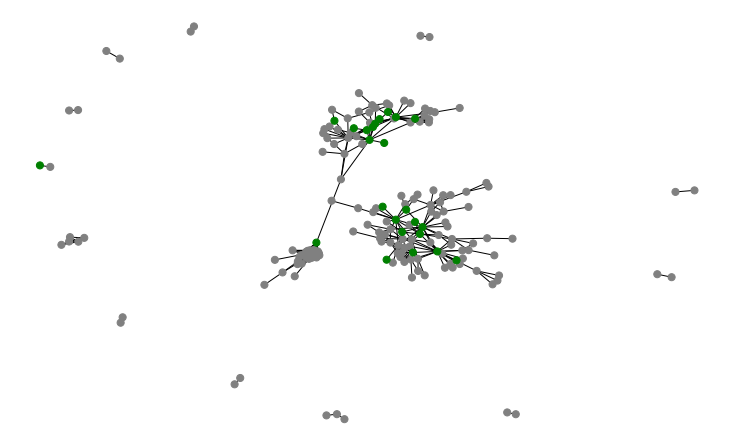

In [27]:
import pandas as pd
import networkx as nx

# Caricamento dei dataset (se non sono già in pandas)
# duplicated_nodes = pd.read_csv("path_to_duplicated_nodes.csv")  # Se hai un CSV
# duplicated_edges = pd.read_csv("path_to_duplicated_edges.csv")

# Creazione del grafo
G = nx.Graph()

# Aggiunta dei nodi con le feature 'label'
for _, row in duplicated_nodes.iterrows():
    G.add_node(row["STRING_id"], label=row["label"])

# Aggiunta degli archi basandosi sui 'STRING_id' del dataset duplicated_edges
for _, row in duplicated_edges.iterrows():
    G.add_edge(row["node1"], row["node2"])

# Verifica
print(f"Numero di nodi: {G.number_of_nodes()}")
print(f"Numero di archi: {G.number_of_edges()}")

import matplotlib.pyplot as plt

# Creiamo una mappa di colori per i nodi: verde per label 2, grigio per gli altri
node_colors = ["green" if "_" in n else "gray" for n in G.nodes]

plt.figure(figsize=(10, 6))
nx.draw(G, node_size=50, font_size=8, node_color=node_colors)
plt.show()

In [28]:
# Escludo le proteine appartenenti alle componenti connesse più piccole (non appartenenti ai grandi gruppi di AD e PD)
# NOTA BENE: sono maggiormente proteine dell'alzheimer

# 1. Ottengo le componenti connesse
l = [component for component in nx.connected_components(G)]
l = sorted(l, key=len, reverse=True)

# 2.  Ottengo le proteine appartenenti alle CC minori
disconnected_components_prots = set()
for c in l[2:]:
    disconnected_components_prots.update(c)

# 3. Le escludo dal dataset dei nodi

duplicated_nodes_main_components = duplicated_nodes.copy()
duplicated_nodes_main_components = duplicated_nodes_main_components[~duplicated_nodes_main_components['STRING_id'].isin(disconnected_components_prots)]

# 4. Escludo gli archi che collegano queste ad altre

duplicated_edges_main_components = duplicated_edges.copy()
duplicated_edges_main_components = duplicated_edges_main_components[~duplicated_edges_main_components['node1'].isin(disconnected_components_prots)]
duplicated_edges_main_components = duplicated_edges_main_components[~duplicated_edges_main_components['node2'].isin(disconnected_components_prots)]

# Reset indici
all_remaining_prots_to_id = {name:index for index, name in enumerate(duplicated_nodes_main_components['STRING_id'].to_list())}
duplicated_nodes_main_components['num_id'] = duplicated_nodes_main_components['STRING_id'].map(all_remaining_prots_to_id)
duplicated_edges_main_components['num_id_1'] = duplicated_edges_main_components['node1'].map(all_remaining_prots_to_id)
duplicated_edges_main_components['num_id_2'] = duplicated_edges_main_components['node2'].map(all_remaining_prots_to_id)

# 5. Output

duplicated_nodes_main_components.to_csv('./pre_processing_output/duplicated_nodes_main_components.csv')
duplicated_edges_main_components.to_csv('./pre_processing_output/duplicated_edges_main_components.csv')